# Malaysia PM₂.₅ — 2023 exploration & summary statistics

QC'd DOE hourly data (65 stations, 15 states), tidied to UTC (`obs_my2023_qc.csv.gz`). Spikes are kept and
marked by `spike_flag`. This notebook:

1. **Network + per-station overview** — who's dirtiest, where.
2. **Per-station time series** — daily mean & max with haze thresholds.
3. **Monthly summary statistics per station** — the per-month table you can read off directly.
4. **Cross-station episode view** — a station×day heatmap where regional haze shows as vertical bands, plus a
   network "how many stations were unhealthy today" line to spot episodes at a glance.

Times are stored UTC; local Malaysian time (MYT = UTC+8) is used for calendar days and the diurnal cycle.

In [1]:
import os
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.25,
                     "axes.spines.top": False, "axes.spines.right": False})

TIDY = "tidy"   # repo-relative: run this notebook from the FM-AQ-KL root
IMG = "img"; os.makedirs(IMG, exist_ok=True)   # every figure is saved here as the notebook runs
obs = pd.read_csv(f"{TIDY}/obs_my2023_qc.csv.gz", parse_dates=["datetime"])
meta = pd.read_csv(f"{TIDY}/stations_my2023.csv")
sc = pd.read_csv(f"{TIDY}/station_qc_scorecard_my2023.csv")[["location_id", "n_spike", "review"]]
meta = meta.merge(sc, on="location_id", how="left")

obs = obs.merge(meta[["location_id", "name", "state"]], on="location_id", how="left")
obs["local"] = obs.datetime + pd.Timedelta(hours=8)          # MYT for calendar / diurnal
obs["date"] = obs.local.dt.floor("D"); obs["month"] = obs.local.dt.month; obs["hour"] = obs.local.dt.hour

# per-station daily mean & max (a "day" is a local Malaysian calendar day)
daily = obs.groupby(["location_id", "date"]).pm25.agg(mean="mean", mx="max").reset_index()

THR = {"WHO 24h (15)": 15, "Unhealthy (55)": 55, "Very unhealthy (150)": 150, "Hazardous (250)": 250}
print(f"{obs.location_id.nunique()} stations | {len(obs):,} hourly obs | "
      f"{obs.local.min():%Y-%m-%d} .. {obs.local.max():%Y-%m-%d} (local)")

65 stations | 565,866 hourly obs | 2023-01-01 .. 2023-12-31 (local)


## 1. Network overview — where is the PM₂.₅?

In [2]:
qn = obs.pm25.describe(percentiles=[.5, .9, .95, .99])
print("network PM2.5 (µg/m³):", {k: round(qn[k], 1) for k in ["mean", "50%", "90%", "95%", "99%", "max"]})

# per-station leaderboard
stn = (obs.groupby("location_id").pm25.agg(mean="mean", p99=lambda s: s.quantile(.99), mx="max").reset_index()
          .merge(meta[["location_id", "name", "state", "lat", "lon", "n_spike", "review"]], on="location_id")
          .sort_values("mean", ascending=False).round(1))
print("\nDirtiest 12 stations (annual mean):")
display(stn.head(12))

print("\nBy state:")
display(obs.groupby("state").pm25.agg(mean="mean", p99=lambda s: s.quantile(.99), mx="max")
           .round(1).sort_values("mean", ascending=False))

network PM2.5 (µg/m³): {'mean': np.float64(15.2), '50%': np.float64(12.4), '90%': np.float64(29.5), '95%': np.float64(36.9), '99%': np.float64(54.3), 'max': np.float64(907.2)}

Dirtiest 12 stations (annual mean):


,location_id,mean,p99,mx,name,state,lat,lon,n_spike,review
20,CA21B,25.1,73.7,905.1,"Klang, SELANGOR",Selangor,3.0,101.4,12,REVIEW
21,CA22B,23.9,65.8,140.9,"Banting, SELANGOR",Selangor,2.8,101.6,0,ok
22,CA23N,22.5,67.4,243.6,"Nilai, NEGERI SEMBILAN",Negeri Sembilan,2.8,101.8,1,ok
15,CA16W,22.1,70.2,604.3,"Cheras, W.P. KUALA LUMPUR",WPKL,3.1,101.7,3,ok
19,CA20B,22.1,67.5,151.2,"Shah Alam, SELANGOR",Selangor,3.1,101.6,1,ok
14,CA15W,21.6,57.5,153.7,"Batu Muda, W.P. KUALA LUMPUR",WPKL,3.2,101.7,1,ok
18,CA19B,21.5,70.0,293.0,"Petaling Jaya, SELANGOR",Selangor,3.1,101.6,7,ok
31,CA33J,21.5,64.5,256.8,"Larkin, JOHOR",Johor,1.5,103.7,3,ok
16,CA17W,21.2,57.6,110.5,"Putrajaya, W.P. PUTRAJAYA",WPLabuan & WPPutrajaya,2.9,101.7,0,ok
26,CA27M,20.3,65.0,122.9,"Bukit Rambai, MELAKA",Melaka,2.3,102.2,2,ok



By state:


,mean,p99,mx
state,,,
Selangor,22.2,68.3,905.1
WPKL,21.9,64.5,604.3
Negeri Sembilan,20.1,62.9,245.5
Melaka,17.8,60.0,122.9
Kelantan,16.9,56.7,107.2
Pulau Pinang,16.4,51.9,221.0
Johor,15.9,56.8,303.0
WPLabuan & WPPutrajaya,15.9,54.9,532.4
Perak,15.3,48.6,210.8


## 2. Per-station time series\nDaily mean (line) and daily max (fill), with haze thresholds.

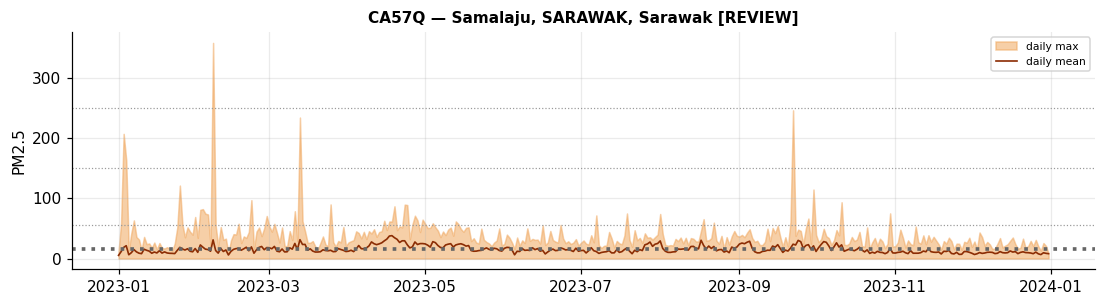

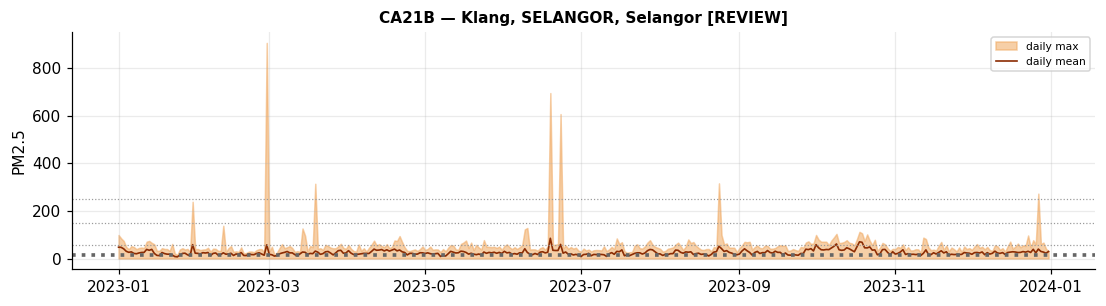

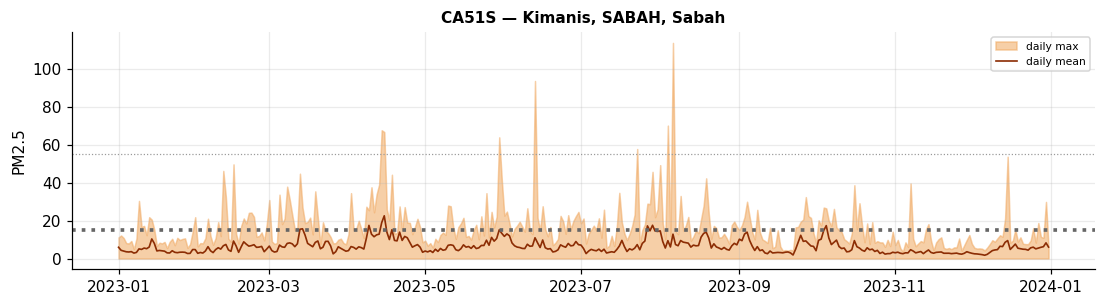

In [3]:
def plot_station(loc, ax=None):
    d = daily[daily.location_id == loc].sort_values("date")
    row = meta[meta.location_id == loc].iloc[0]
    own = ax is None
    if own:
        fig, ax = plt.subplots(figsize=(12, 2.8))
    ax.fill_between(d.date, 0, d.mx, color="#f0a860", alpha=.55, label="daily max")
    ax.plot(d.date, d["mean"], color="#8c2d04", lw=1.1, label="daily mean")
    for t in THR.values():
        if t <= max(70, d.mx.max()):
            who = (t == 15)     # emphasise the WHO 24 h guideline
            ax.axhline(t, color="0.4" if who else "0.6", ls=":", lw=2.4 if who else .8)
    tag = " [REVIEW]" if row.review == "REVIEW" else ""
    ax.set_title(f"{loc} — {row['name']}, {row.state}{tag}", fontsize=10, fontweight="bold")
    ax.set_ylabel("PM2.5"); ax.legend(fontsize=7, loc="upper right")
    if own:
        fig.savefig(f"{IMG}/station_{loc}.png", dpi=140, bbox_inches="tight")
    return ax

# a hazy East-Malaysia site, the dirtiest and cleanest by annual mean, and a REVIEW station
examples = ["CA57Q", stn.iloc[0].location_id, stn.iloc[-1].location_id]
for loc in dict.fromkeys(examples):
    plot_station(loc); plt.show()

*Approach:* aggregate each station's hourly PM₂.₅ to a daily **mean** (line) and daily **max** (fill), and
overlay the health thresholds. *Plotted:* three contrasting stations — a hazy East-Malaysia site, and the
dirtiest and cleanest by annual mean. *Conclusion:* pollution is **event-driven** — long stretches near the WHO
line punctuated by multi-day excursions where the daily max runs far above the mean; baseline and event
intensity differ sharply between stations, so a single network number hides a lot.

## 3. Monthly summary statistics (per station)

`monthly_stats(loc)` returns the per-month table (mean / median / p95 / max / exceedance days) for one station.
`monthly` is the tidy long table for every station × month, also written to `monthly_stats_my2023.csv`.

In [4]:
def monthly_stats(loc):
    d = obs[obs.location_id == loc]
    m = d.groupby("month").pm25.agg(n_hours="count", mean="mean", median="median",
                                    p95=lambda s: s.quantile(.95), mx="max")
    dd = daily[daily.location_id == loc]
    m["days_>35(daily mean)"] = dd.groupby(dd.date.dt.month)["mean"].apply(lambda g: int((g > 35).sum()))
    m["days_>55(daily max)"] = dd.groupby(dd.date.dt.month)["mx"].apply(lambda g: int((g > 55).sum()))
    return m.round(1)

print("Monthly summary — CA21B (Selangor):")
display(monthly_stats("CA21B"))

monthly = (obs.groupby(["location_id", "state", "month"]).pm25
              .agg(mean="mean", p95=lambda s: s.quantile(.95), mx="max").round(2).reset_index())
monthly.to_csv(f"{TIDY}/monthly_stats_my2023.csv", index=False)
print("wrote monthly_stats_my2023.csv", monthly.shape)

Monthly summary — CA21B (Selangor):


,n_hours,mean,median,p95,mx,days_>35(daily mean),days_>55(daily max)
month,,,,,,,
1,733,25.0,21.1,59.8,238.1,6,9
2,672,20.4,17.4,37.7,905.1,1,2
3,744,22.3,20.1,43.6,313.9,0,6
4,706,26.8,24.7,50.0,94.1,7,10
5,744,21.7,20.4,43.2,77.2,0,7
6,720,27.0,22.4,50.8,694.5,3,9
7,744,20.9,17.9,48.9,84.4,3,7
8,744,23.9,21.6,47.1,315.5,3,9
9,720,25.3,23.9,50.3,72.0,4,9


wrote monthly_stats_my2023.csv (780, 6)


## 4. Spotting high-PM₂.₅ episodes across stations

The heatmap is the key view: **rows are stations (grouped by state, south→north-ish by latitude), columns are
days, colour is that day's peak PM₂.₅.** A regional haze episode lights up a **vertical band** — many stations
high on the same days. A single flaky sensor shows as an isolated bright cell in one row.

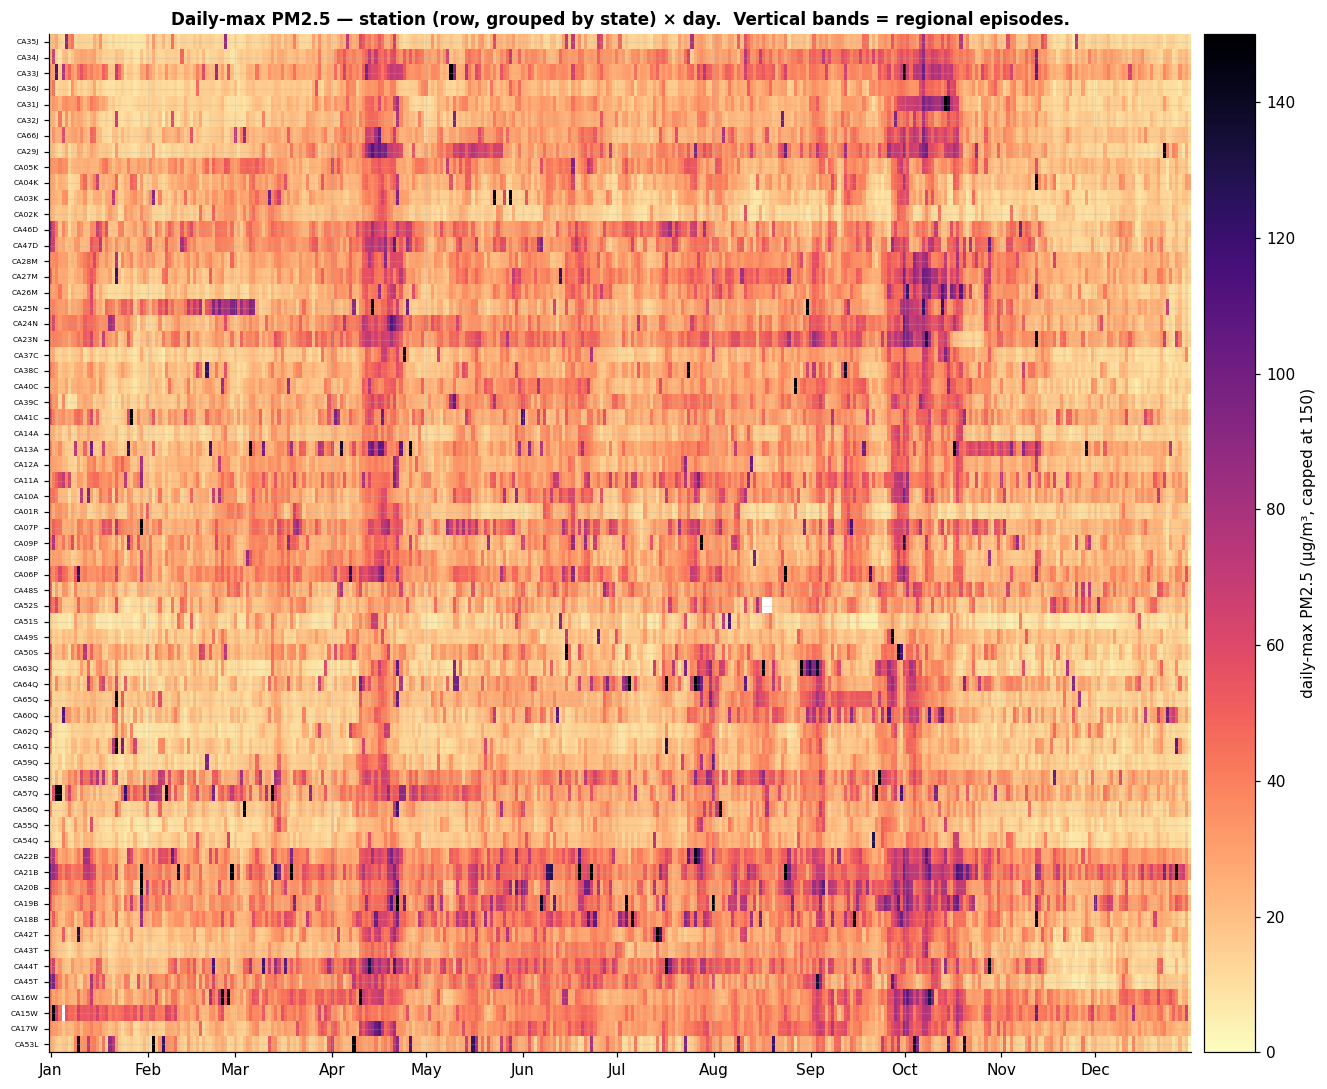

In [5]:
piv = daily.pivot(index="location_id", columns="date", values="mx")
order = meta.sort_values(["state", "lat"]).location_id
order = [s for s in order if s in piv.index]
piv = piv.reindex(order)

fig, ax = plt.subplots(figsize=(13, 10))
im = ax.imshow(piv.values, aspect="auto", cmap="magma_r", vmin=0, vmax=150, interpolation="nearest")
ax.set_yticks(range(len(piv))); ax.set_yticklabels(piv.index, fontsize=5)
mstart = [pd.Timestamp(2023, mo, 1) for mo in range(1, 13)]
xt = [(t - piv.columns.min()).days for t in mstart]
ax.set_xticks(xt); ax.set_xticklabels([t.strftime("%b") for t in mstart])
ax.set_title("Daily-max PM2.5 — station (row, grouped by state) × day.  Vertical bands = regional episodes.",
             fontsize=11, fontweight="bold")
cb = fig.colorbar(im, ax=ax, pad=.01); cb.set_label("daily-max PM2.5 (µg/m³, capped at 150)")
plt.tight_layout(); fig.savefig(f"{IMG}/heatmap_station_day_dailymax.png", dpi=140, bbox_inches="tight"); plt.show()

*Approach:* pivot daily-max PM₂.₅ into a station (row) × day (column) grid, rows grouped by state then
latitude, on a sequential colour scale capped at 150. *Plotted:* every station's daily peak across all of 2023
in one panel. *Conclusion:* regional episodes read as **vertical bands** (many stations high on the same days) —
the **Sept–Oct 2023 transboundary haze** stands out across nearly every station (peninsular *and* Borneo), with
a secondary April band; isolated bright single cells in one row are the flagged sensor spikes, not episodes.

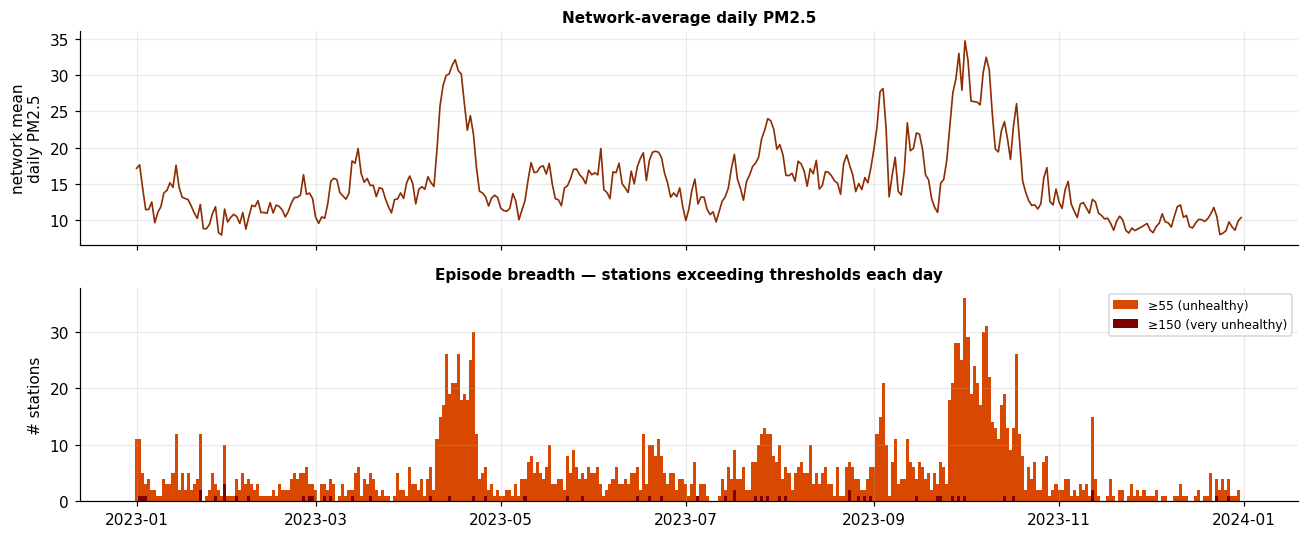

Top 12 network episode days (most stations ≥55 µg/m³ daily-max):


/var/folders/_m/cjtrrw9s08s97gdw4pt08t1h0000gn/T/ipykernel_98943/1071853596.py:15: UserWarning: obj.round has no effect with datetime, timedelta, or period dtypes. Use obj.dt.round(...) instead.
  display(nd.sort_values("n_gt55", ascending=False).head(12).round(1))


,date,net_mean,net_max,n_gt55,n_gt150
273,2023-10-01,34.7,256.8,36,1
280,2023-10-08,32.5,129.0,31,0
111,2023-04-22,21.9,293.0,30,1
279,2023-10-07,30.4,121.1,30,0
274,2023-10-02,32.0,121.7,29,0
271,2023-09-29,33.0,292.1,28,1
270,2023-09-28,29.4,92.8,28,0
106,2023-04-17,30.6,106.3,26,0
102,2023-04-13,29.9,131.1,26,0
290,2023-10-18,26.1,111.9,26,0


In [6]:
# network episode timeline: average level + how many stations were unhealthy each day
nd = daily.groupby("date").agg(net_mean=("mean", "mean"), net_max=("mx", "max"),
                               n_gt55=("mx", lambda s: int((s >= 55).sum())),
                               n_gt150=("mx", lambda s: int((s >= 150).sum()))).reset_index()
fig, ax = plt.subplots(2, 1, figsize=(12, 5), sharex=True)
ax[0].plot(nd.date, nd.net_mean, color="#8c2d04", lw=1.1)
ax[0].set_ylabel("network mean\ndaily PM2.5"); ax[0].set_title("Network-average daily PM2.5", fontsize=10, fontweight="bold")
ax[1].bar(nd.date, nd.n_gt55, color="#d94801", width=1, label="≥55 (unhealthy)")
ax[1].bar(nd.date, nd.n_gt150, color="#7f0000", width=1, label="≥150 (very unhealthy)")
ax[1].set_ylabel("# stations"); ax[1].legend(fontsize=8)
ax[1].set_title("Episode breadth — stations exceeding thresholds each day", fontsize=10, fontweight="bold")
plt.tight_layout(); fig.savefig(f"{IMG}/network_episode_timeline.png", dpi=140, bbox_inches="tight"); plt.show()

print("Top 12 network episode days (most stations ≥55 µg/m³ daily-max):")
display(nd.sort_values("n_gt55", ascending=False).head(12).round(1))

*Approach:* aggregate each station's hourly PM₂.₅ to a daily **mean** (line) and daily **max** (fill), and
overlay the health thresholds. *Plotted:* three contrasting stations — a hazy East-Malaysia site, and the
dirtiest and cleanest by annual mean. *Conclusion:* pollution is **event-driven** — long stretches near the WHO
line punctuated by multi-day excursions where the daily max runs far above the mean; baseline and event
intensity differ sharply between stations, so a single network number hides a lot.

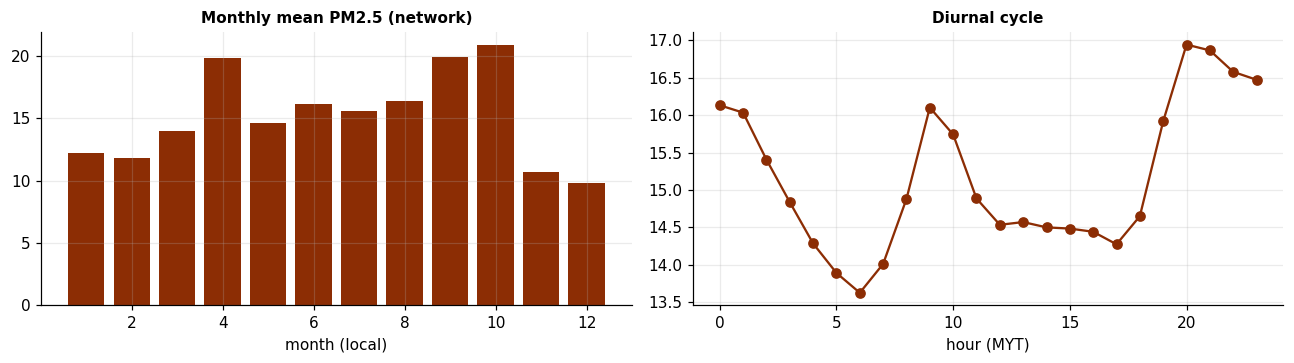

In [7]:
# seasonality and diurnal cycle
fig, ax = plt.subplots(1, 2, figsize=(12, 3.4))
mc = obs.groupby("month").pm25.mean()
ax[0].bar(mc.index, mc.values, color="#8c2d04"); ax[0].set_xlabel("month (local)")
ax[0].set_title("Monthly mean PM2.5 (network)", fontsize=10, fontweight="bold")
dc = obs.groupby("hour").pm25.mean()
ax[1].plot(dc.index, dc.values, marker="o", color="#8c2d04"); ax[1].set_xlabel("hour (MYT)")
ax[1].set_title("Diurnal cycle", fontsize=10, fontweight="bold")
plt.tight_layout(); fig.savefig(f"{IMG}/seasonality_diurnal.png", dpi=140, bbox_inches="tight"); plt.show()

*Approach:* network-mean PM₂.₅ by calendar month and by local hour-of-day. *Plotted:* (left) seasonality;
(right) the mean diurnal cycle in local time. *Conclusion:* seasonality is **bimodal** (Feb–Apr and Aug–Oct
burning windows). The diurnal cycle is a strong **double peak** — a morning peak (~09:00) and an evening peak
(~20:00) either side of an afternoon minimum, driven by the boundary layer trapping emissions at night/morning
and diluting them under deep daytime mixing. Note for fine-tuning: **Aurora's 00/12 UTC steps land at 08:00 and
20:00 MYT** — the two *high* phases — so single-frame supervision would bake in a diurnal bias.